<a href="https://colab.research.google.com/github/mjss26/EMSC2010-W10-L1-MSS/blob/main/EMSC2010_W10_L1_NB4_MSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-L1-NB4

Use this notebook to process the Japanese cherry blossoms data and see if you can find a pattern in the long term data.

The excel data file ```blossom_doy.xlsx``` contains two variables:


1.   ```year```: The year of the cherry bloom.
2.   ```doy```: The day of the year of the first cherry bloom (where day 0 corresponds to January 1)

Don't forget to use the code in ```EMSC2010-W10-L1-NB2``` and ```EMSC2010-W10-L1-NB3``` as a template for this problem.



In [ ]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd # Pandas for data manipulation

In [ ]:
file = 'blossom_doy.xlsx' #define the name of the data file
df = pd.read_excel(file) #read the file into a dataframe
df.head() #show the dataframe header

,year,doy
0,812,92
1,815,105
2,831,96
3,851,108
4,853,104


In [ ]:
df_doy = df[['year', 'doy']].copy() #new dateframe with the variables we need
df_doy = df_doy.dropna() #remove rows with missing values
year = df_doy['year'].to_numpy() #convert dates into numpy array
doy = df_doy['doy'].to_numpy() #convert doy into numpy array

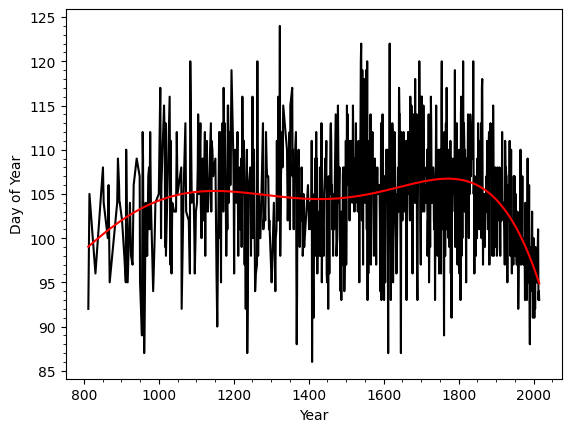

In [ ]:
order = 5 #set the polynomial order
pp = np.polyfit(year,doy,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,year) #find the value of the polynomial at each time point.

plt.plot(year,doy,'k') #plot the data
plt.plot(year,trend,'r') #plot the trend
plt.xlabel('Year') #label the x-axis
plt.ylabel('Day of Year') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

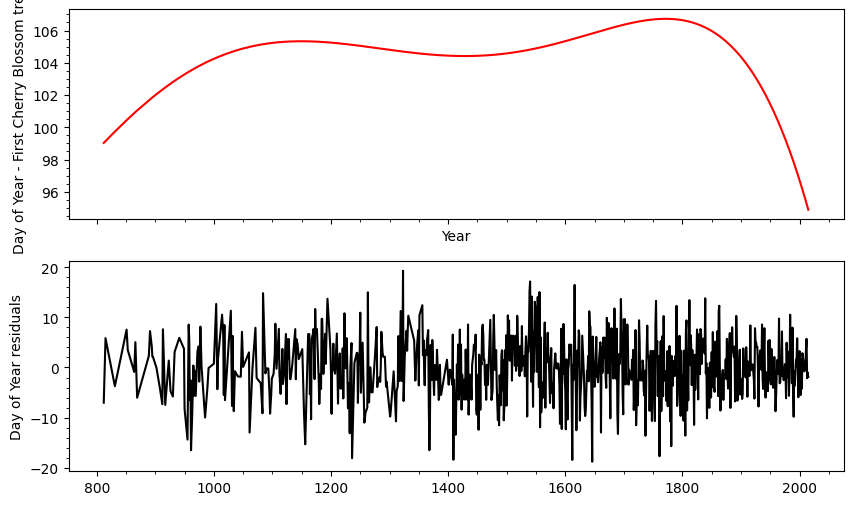

In [ ]:
residuals = doy-trend #find the residuals
fig, axes = plt.subplots(2,1, figsize=(10, 6), sharex = True) #make 2 subplots with the same x-axis

axes[0].plot(year,trend,'r') #plot the polynomial trend
axes[1].plot(year,residuals,'k') #plot the residuals

axes[0].set_xlabel('Year') #label the x-axis
axes[0].set_ylabel('Day of Year - First Cherry Blossom trend') #label the trend y-axis
axes[1].set_ylabel('Day of Year residuals') #label the residual y-axis

axes[0].minorticks_on() #add minorticks
axes[1].minorticks_on() #add minorticks

In [ ]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

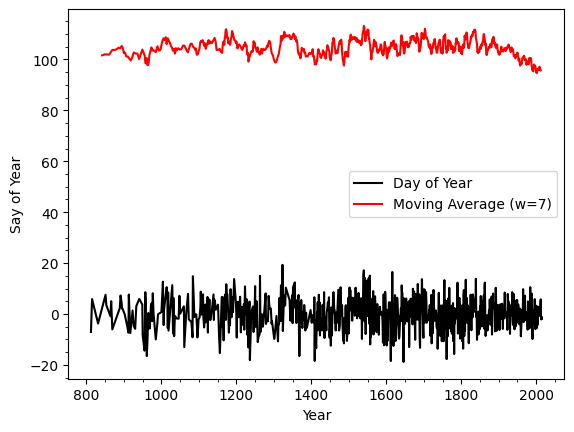

In [ ]:
w = 7 #length of the moving average #always odd numbers - ie 3 point average or more #the larger the moving average, the smoother the signal will be
ys = moving_average(doy, w)
ts = moving_average(year, w)

plt.plot(year_doy,residuals,'k',label='Day of Year')
plt.plot(ts,ys,'r',label=f'Moving Average (w={w})') #plot the moving average
plt.xlabel('Year') #label the x-axis
plt.ylabel('Say of Year') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks